<a href="https://colab.research.google.com/github/pgstorm148/wearable_tech_analysis/blob/main/wearable_tech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p biometric_wearable output

In [2]:
!pip install numpy scipy matplotlib pandas

In [3]:
!python run.py --duration 30 --stress-at 10,20 --nfc-taps 4 --no-dashboard

Generating synthetic data...
Starting pipeline...
NFC end_session received. Stopping.
Saved fusion log to ./output/fusion_log.csv
Saved NFC events to ./output/nfc_events.json


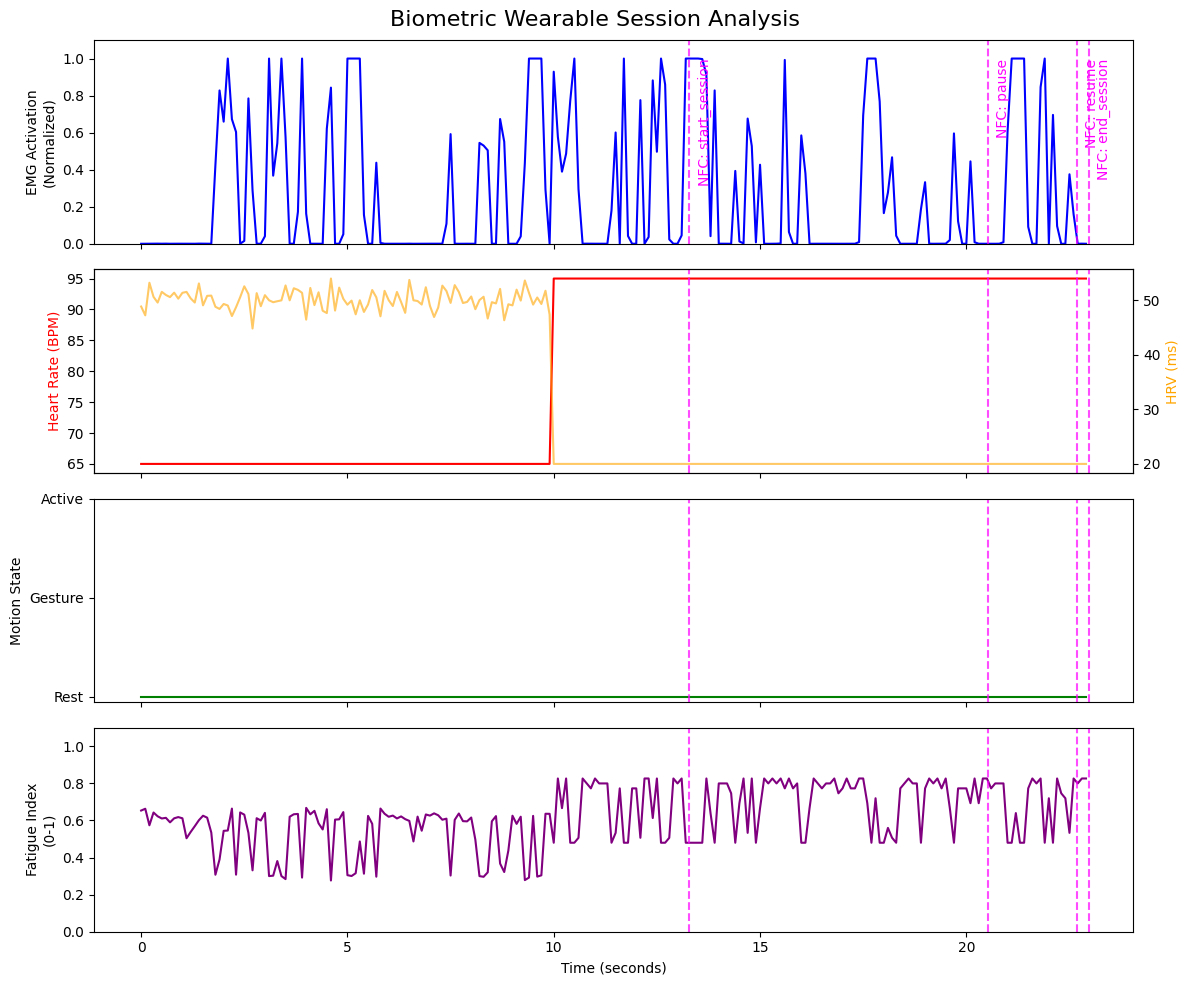

In [4]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# 1. Load the generated data
df = pd.read_csv('./output/fusion_log.csv')
with open('./output/nfc_events.json', 'r') as f:
    nfc_events = json.load(f)

# Convert timestamp to seconds for easier reading
df['time_sec'] = df['timestamp_ms'] / 1000.0

# 2. Create the plot
fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Biometric Wearable Session Analysis', fontsize=16)

# Plot 1: EMG Activation
axs[0].plot(df['time_sec'], df['emg_activation'], color='blue')
axs[0].set_ylabel('EMG Activation\n(Normalized)')
axs[0].set_ylim(0, 1.1)

# Plot 2: Heart Rate & HRV
ax2_hr = axs[1]
ax2_hrv = axs[1].twinx()
ax2_hr.plot(df['time_sec'], df['hr_bpm'], color='red', label='HR (BPM)')
ax2_hrv.plot(df['time_sec'], df['hrv_rmssd'], color='orange', alpha=0.6, label='HRV (RMSSD)')
ax2_hr.set_ylabel('Heart Rate (BPM)', color='red')
ax2_hrv.set_ylabel('HRV (ms)', color='orange')

# Plot 3: Motion State
# Convert categorical motion states to numeric for plotting
motion_map = {'rest': 0, 'gesture': 1, 'active': 2}
df['motion_numeric'] = df['motion_state'].map(motion_map)
axs[2].step(df['time_sec'], df['motion_numeric'], color='green', where='post')
axs[2].set_yticks([0, 1, 2])
axs[2].set_yticklabels(['Rest', 'Gesture', 'Active'])
axs[2].set_ylabel('Motion State')

# Plot 4: Fatigue Index
axs[3].plot(df['time_sec'], df['fatigue_index'], color='purple')
axs[3].set_ylabel('Fatigue Index\n(0-1)')
axs[3].set_xlabel('Time (seconds)')
axs[3].set_ylim(0, 1.1)

# 3. Add NFC Event Markers
for event in nfc_events:
    t_sec = event['timestamp_ms'] / 1000.0
    action = event['action']
    for ax in axs:
        ax.axvline(x=t_sec, color='magenta', linestyle='--', alpha=0.7)
    axs[0].text(t_sec + 0.2, 1.0, f"NFC: {action}", color='magenta', rotation=90, va='top')

plt.tight_layout()
plt.show()